# GRU — Weekend Gap Prediction

**Role in the project:** Sequential model for temporal pattern detection — a direct architectural alternative to the LSTM.

**GRU vs LSTM:**  
GRU (Gated Recurrent Unit) uses two gates — reset and update — versus LSTM's three (input, forget, output). It has no separate cell state; the hidden state itself carries memory. This makes GRU:
- Fewer parameters (roughly 25% less than LSTM for the same hidden size)
- Faster to train on small datasets
- Often competitive in performance on short sequences

**Everything else is identical to the LSTM notebook:** same dataset, same 14 features, same WINDOW=4 week sequences, same rolling 3-year walk-forward folds, same hyperparameter grid, same evaluation metrics.

**Research question:** Does the simpler GRU gating mechanism perform differently from LSTM on this dataset, or does the choice of recurrent cell not matter much given the weak signal in weekly gap data?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

PyTorch 2.7.0  |  device: cpu


## 1. Load Data & Define Feature Set

In [19]:
df_all  = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv',
                      parse_dates=['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {primary["GapUp"].mean():.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {extreme["GapUp"].mean():.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [20]:
# Identical feature set to the LSTM notebook.
# No fundamentals (flat quarterly values give GRU gates nothing temporal to learn).
# No missingness indicators (encode data quality, not market dynamics).

MOMENTUM   = ['RSI', 'MACD', 'ROC', 'StochPercK']
TREND      = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME     = ['OBV', 'MFI', 'VolumeRatio']
PRICE_AGG  = ['WeeklyRange']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + PRICE_AGG
TARGET   = 'GapUp'
WINDOW   = 4   # 4-week lookback — same as LSTM

print(f'Feature count:    {len(FEATURES)}')
print(f'Sequence window:  {WINDOW} weeks')
missing = [f for f in FEATURES if f not in primary.columns]
print(f'Missing columns: {missing if missing else "None — all 14 present"}')

Feature count:    14
Sequence window:  4 weeks
Missing columns: None — all 14 present


## 2. Preprocessing — Required for GRU

Same as LSTM: `StandardScaler` fitted on training sequences only (all timesteps flattened). GRU gates use sigmoid and tanh internally — large unscaled inputs saturate these activations and kill gradient flow during backpropagation.

## 3. Sequence Construction — 4-Week Sliding Window

Identical to LSTM: per-ticker sliding window of length 4. The target week's year determines fold membership.

In [21]:
def build_sequences(df, features, target, window=4):
    """
    Builds per-ticker sliding window sequences.
    Returns X (N, window, n_features), y (N,), years (N,), extreme_flags (N,).
    """
    X_list, y_list, yr_list, ex_list = [], [], [], []
    has_extreme = 'is_extreme_event' in df.columns

    for ticker, grp in df.sort_values(['Ticker', 'Date']).groupby('Ticker'):
        grp       = grp.reset_index(drop=True)
        feat_vals = grp[features].values.astype(np.float32)
        tgt_vals  = grp[target].values.astype(np.float32)
        yr_vals   = grp['Year'].values
        ex_vals   = grp['is_extreme_event'].values if has_extreme else np.zeros(len(grp), dtype=int)

        for i in range(window - 1, len(grp)):
            X_list.append(feat_vals[i - window + 1 : i + 1])
            y_list.append(tgt_vals[i])
            yr_list.append(yr_vals[i])
            ex_list.append(ex_vals[i])

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(yr_list),
            np.array(ex_list))


X_all, y_all, years_all, _ = build_sequences(primary, FEATURES, TARGET, WINDOW)

print(f'Total sequences:  {len(X_all):,}')
print(f'Sequence shape:   {X_all.shape}  (N, window, features)')
print(f'GapUp rate:       {y_all.mean():.3f}')
print()
print('Sequences per year:')
for yr in sorted(np.unique(years_all)):
    print(f'  {yr}: {(years_all == yr).sum():,}')

Total sequences:  8,071
Sequence shape:   (8071, 4, 14)  (N, window, features)
GapUp rate:       0.517

Sequences per year:
  2016: 662
  2017: 979
  2018: 966
  2019: 992
  2020: 613
  2021: 917
  2022: 997
  2023: 953
  2024: 992


## 4. GRU Architecture

Single-layer GRU with a linear output head.

| Component | Detail |
|-----------|--------|
| GRU layer | 1 layer, hidden_size tuned |
| Last timestep | `out[:, -1, :]` — carries sequence history via GRU memory |
| Dropout | After GRU, before linear |
| Linear + Sigmoid | Maps hidden → [0,1] probability of GapUp |

**Improvements over naive baseline:**
- **Smaller hidden sizes {8, 16}** — fewer parameters reduces overfitting on ~3k training sequences
- **Elastic-net regularization** — L2 via `weight_decay=1e-4` in Adam (always on); L1 via explicit penalty in the loss (tuned in grid search). Combined, they penalise large weights and encourage sparse representations.

In [22]:
class GRUGapPredictor(nn.Module):
    """
    Single-layer GRU for binary weekend gap prediction.
    Input:  (batch, seq_len=4, input_size)
    Output: (batch,) — sigmoid probability of GapUp
    """
    def __init__(self, input_size, hidden_size, dropout=0.2):
        super().__init__()
        self.gru     = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                               num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)          # (batch, seq_len, hidden)
        out    = out[:, -1, :]        # last timestep: (batch, hidden)
        out    = self.dropout(out)
        return torch.sigmoid(self.fc(out)).squeeze(-1)

In [23]:
def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate(model, X, y):
    """Return (auc, accuracy, predicted_probabilities)."""
    model.eval()
    with torch.no_grad():
        proba = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    preds = (proba >= 0.5).astype(int)
    return roc_auc_score(y, proba), accuracy_score(y, preds), proba


def fit_model(X_train, y_train, X_val, y_val,
              hidden_size, dropout,
              l1_weight=0.0, weight_decay=1e-4,
              lr=0.001, max_epochs=50, patience=10, batch_size=64):
    """
    Trains GRUGapPredictor with elastic-net regularization and early stopping.
    L2: weight_decay in Adam. L1: explicit penalty added to BCE loss.
    """
    model     = GRUGapPredictor(X_train.shape[2], hidden_size, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCELoss()
    loader    = make_loader(X_train, y_train, batch_size=batch_size)

    best_auc, best_state, wait = -np.inf, None, 0

    for _ in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            if l1_weight > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss    = loss + l1_weight * l1_norm
            loss.backward()
            optimizer.step()

        val_auc, _, _ = evaluate(model, X_val, y_val)
        if val_auc > best_auc + 1e-4:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_auc

## 5. Walk-Forward Validation & Hyperparameter Tuning

Rolling 3-year window, 6 folds. The grid searches over hidden size, dropout, and L1 regularization strength:

| Parameter | Grid | Rationale |
|-----------|------|-----------|
| `hidden_size` | 8, 16 | Smaller than LSTM baseline — less overfitting on ~3k sequences |
| `dropout` | 0.2, 0.3 | Same as LSTM |
| `l1_weight` | 0, 1e-4 | Grid-searches whether L1 penalty helps |
| `weight_decay` | 1e-4 | L2 via Adam — fixed, always applied |

In [24]:
FOLDS = [
    {'train_years': [2016, 2017, 2018], 'test_year': 2019},
    {'train_years': [2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2021, 2022, 2023], 'test_year': 2024},
]

PARAM_GRID = [
    {'hidden_size': h, 'dropout': d, 'l1_weight': l1}
    for h  in [8, 16]
    for d  in [0.2, 0.3]
    for l1 in [0.0, 1e-4]
]

print(f'Model:                   BidirGRUGapPredictor (bidirectional, L1+L2 reg)')
print(f'Training strategy:       Rolling 3-year window')
print(f'Hyperparameter combos:   {len(PARAM_GRID)}')
print(f'L2 weight_decay:         1e-4 (fixed in Adam)')
print()
for fold in FOLDS:
    n_train = np.isin(years_all, fold['train_years']).sum()
    n_test  = (years_all == fold['test_year']).sum()
    yr_range = f"{fold['train_years'][0]}-{fold['train_years'][-1]}"
    print(f"  Train {yr_range} ({n_train:,} seqs) → Test {fold['test_year']} ({n_test:,} seqs)")

Model:                   BidirGRUGapPredictor (bidirectional, L1+L2 reg)
Training strategy:       Rolling 3-year window
Hyperparameter combos:   8
L2 weight_decay:         1e-4 (fixed in Adam)

  Train 2016-2018 (2,607 seqs) → Test 2019 (992 seqs)
  Train 2017-2019 (2,937 seqs) → Test 2020 (613 seqs)
  Train 2018-2020 (2,571 seqs) → Test 2021 (917 seqs)
  Train 2019-2021 (2,522 seqs) → Test 2022 (997 seqs)
  Train 2020-2022 (2,527 seqs) → Test 2023 (953 seqs)
  Train 2021-2023 (2,867 seqs) → Test 2024 (992 seqs)


In [25]:
fold_results     = []
fold_best_params = []
fold_proba       = []
fold_y_test      = []
fold_importances = []

scaler = StandardScaler()

for fold in FOLDS:
    test_year     = fold['test_year']
    train_years   = fold['train_years']
    inner_val_yr  = max(train_years)
    inner_trn_yrs = [y for y in train_years if y != inner_val_yr]

    mask_itrn = np.isin(years_all, inner_trn_yrs)
    mask_ival  = (years_all == inner_val_yr)
    mask_full  = np.isin(years_all, train_years)
    mask_test  = (years_all == test_year)

    X_itrn, y_itrn = X_all[mask_itrn], y_all[mask_itrn]
    X_ival,  y_ival  = X_all[mask_ival],  y_all[mask_ival]
    X_full,  y_full  = X_all[mask_full],  y_all[mask_full]
    X_test,  y_test  = X_all[mask_test],  y_all[mask_test]

    n_feat = X_full.shape[2]
    scaler.fit(X_full.reshape(-1, n_feat))

    def sc(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape).astype(np.float32)

    Xi_s = sc(X_itrn); Xv_s = sc(X_ival)
    Xf_s = sc(X_full); Xt_s = sc(X_test)

    # Hyperparameter search on inner split
    best_val_auc, best_params = -np.inf, None
    for params in PARAM_GRID:
        torch.manual_seed(42)
        _, val_auc = fit_model(Xi_s, y_itrn, Xv_s, y_ival, **params)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_params  = params.copy()

    # Refit best config on full training window
    torch.manual_seed(42)
    best_model, _ = fit_model(Xf_s, y_full, Xv_s, y_ival, **best_params)

    auc, acc, proba = evaluate(best_model, Xt_s, y_test)
    preds    = (proba >= 0.5).astype(int)
    baseline = max(y_test.mean(), 1 - y_test.mean())

    fold_results.append({
        'Test year':   test_year,
        'Accuracy':    round(acc, 4),
        'Precision':   round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':      round(recall_score(y_test, preds, zero_division=0), 4),
        'F1':          round(f1_score(y_test, preds, zero_division=0), 4),
        'AUC-ROC':     round(auc, 4),
        'Baseline':    round(baseline, 4),
        'hidden_size': best_params['hidden_size'],
        'dropout':     best_params['dropout'],
        'l1_weight':   best_params['l1_weight'],
    })
    fold_best_params.append(best_params)
    fold_proba.append(proba)
    fold_y_test.append(y_test)

    # Permutation importance (5 shuffles per feature)
    perm_imp = {}
    for fi, feat in enumerate(FEATURES):
        drops = []
        for _ in range(5):
            Xp = Xt_s.copy()
            Xp[:, :, fi] = Xp[np.random.permutation(Xp.shape[0]), :, fi]
            p_auc, _, _ = evaluate(best_model, Xp, y_test)
            drops.append(p_auc)
        perm_imp[feat] = round(auc - np.mean(drops), 5)
    fold_importances.append(perm_imp)

    h  = best_params['hidden_size']
    dr = best_params['dropout']
    l1 = best_params['l1_weight']
    print(f'Fold test={test_year} | hidden={h:2d} dropout={dr} l1={l1:.0e} | '
          f'Acc={acc:.3f} AUC={auc:.3f} Baseline={baseline:.3f}')

Fold test=2019 | hidden=16 dropout=0.3 l1=1e-04 | Acc=0.529 AUC=0.541 Baseline=0.526
Fold test=2020 | hidden=16 dropout=0.2 l1=0e+00 | Acc=0.573 AUC=0.566 Baseline=0.564
Fold test=2021 | hidden=16 dropout=0.3 l1=1e-04 | Acc=0.541 AUC=0.560 Baseline=0.514
Fold test=2022 | hidden=16 dropout=0.2 l1=1e-04 | Acc=0.496 AUC=0.546 Baseline=0.588
Fold test=2023 | hidden= 8 dropout=0.2 l1=1e-04 | Acc=0.545 AUC=0.552 Baseline=0.511
Fold test=2024 | hidden=16 dropout=0.2 l1=1e-04 | Acc=0.534 AUC=0.547 Baseline=0.573


## 6. Walk-Forward Results

In [26]:
results_df = pd.DataFrame(fold_results).set_index('Test year')

display(results_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

non_covid = results_df[results_df.index != 2020]
print(f'\nAverage metrics (excluding COVID fold):')
print(f'  Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  F1:        {non_covid["F1"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Baseline:  {non_covid["Baseline"].mean():.4f}')

,Accuracy,Precision,Recall,F1,AUC-ROC,Baseline,hidden_size,dropout,l1_weight
Test year,,,,,,,,,
2019,0.5292,0.5459,0.6264,0.5834,0.5409,0.5262,16,0.300000,0.000100
2020,0.5726,0.6186,0.6329,0.6257,0.5665,0.5644,16,0.200000,0.000000
2021,0.5409,0.5439,0.6582,0.5956,0.5600,0.5136,16,0.300000,0.000100
2022,0.4965,0.4355,0.7470,0.5502,0.5460,0.5878,16,0.200000,0.000100
2023,0.5446,0.5331,0.5536,0.5432,0.5517,0.5110,8,0.200000,0.000100
2024,0.5343,0.6205,0.4806,0.5417,0.5472,0.5726,16,0.200000,0.000100



Average metrics (excluding COVID fold):
  Accuracy:  0.5291
  Precision: 0.5358
  Recall:    0.6132
  F1:        0.5628
  AUC-ROC:   0.5492
  Baseline:  0.5422


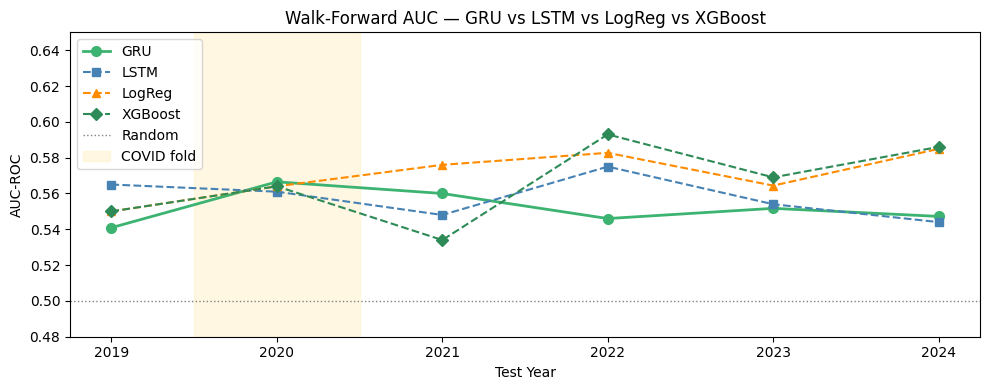

In [27]:
# AUC per fold — GRU vs other models.
# LSTM, LogReg, XGBoost values from their respective notebooks.

lstm_aucs   = {2019: 0.5650, 2020: 0.5610, 2021: 0.5480, 2022: 0.5750, 2023: 0.5540, 2024: 0.5440}
logreg_aucs = {2019: 0.5500, 2020: 0.5640, 2021: 0.5760, 2022: 0.5827, 2023: 0.5644, 2024: 0.5849}
xgb_aucs    = {2019: 0.5500, 2020: 0.5640, 2021: 0.5340, 2022: 0.5930, 2023: 0.5690, 2024: 0.5860}

test_years = results_df.index.tolist()
gru_auc  = results_df['AUC-ROC'].tolist()
lstm_auc = [lstm_aucs[y] for y in test_years]
lr_auc   = [logreg_aucs[y] for y in test_years]
xg_auc   = [xgb_aucs[y] for y in test_years]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_years, gru_auc,  'o-',  color='mediumseagreen', lw=2, ms=7, label='GRU')
ax.plot(test_years, lstm_auc, 's--', color='steelblue',       lw=1.5, ms=6, label='LSTM')
ax.plot(test_years, lr_auc,   '^--', color='darkorange',      lw=1.5, ms=6, label='LogReg')
ax.plot(test_years, xg_auc,   'D--', color='seagreen',        lw=1.5, ms=6, label='XGBoost')
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.6, label='COVID fold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('Walk-Forward AUC — GRU vs LSTM vs LogReg vs XGBoost')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

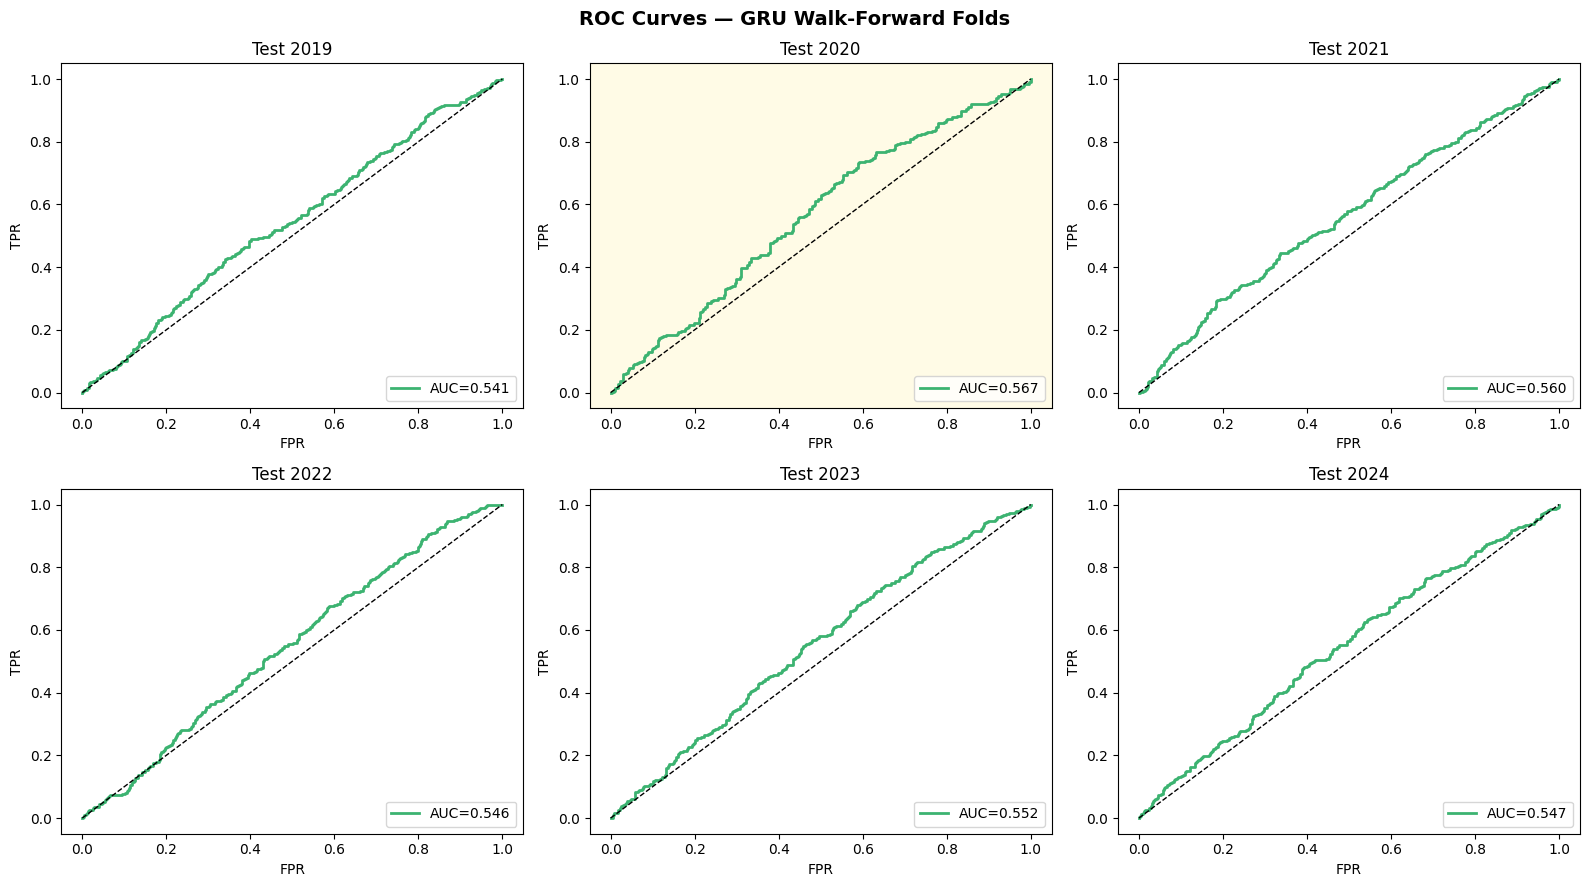

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test, fold_results)):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax = axes[i]
    ax.plot(fpr, tpr, color='mediumseagreen', lw=2, label=f'AUC={row["AUC-ROC"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
    if row['Test year'] == 2020:
        ax.set_facecolor('#fffbe6')

fig.suptitle('ROC Curves — GRU Walk-Forward Folds', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

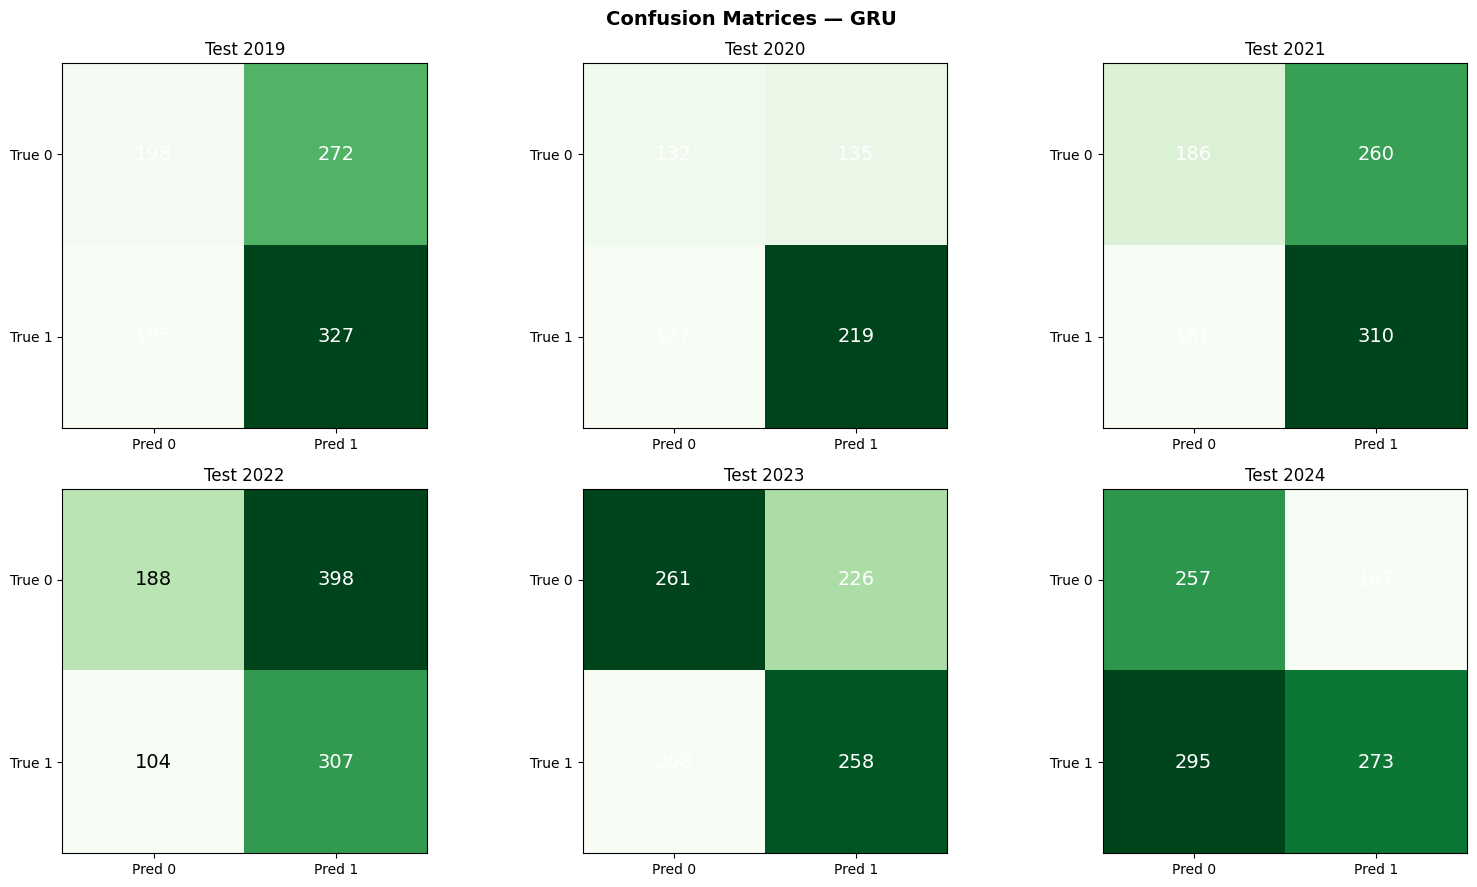

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test, fold_results)):
    preds = (proba >= 0.5).astype(int)
    cm    = confusion_matrix(y_test, preds)
    ax    = axes[i]
    ax.imshow(cm, cmap='Greens')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center', fontsize=14,
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)

fig.suptitle('Confusion Matrices — GRU', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Permutation Feature Importance

Same methodology as LSTM: shuffle each feature across sequences, measure AUC drop. Positive drop = the feature contributes to GRU predictions.

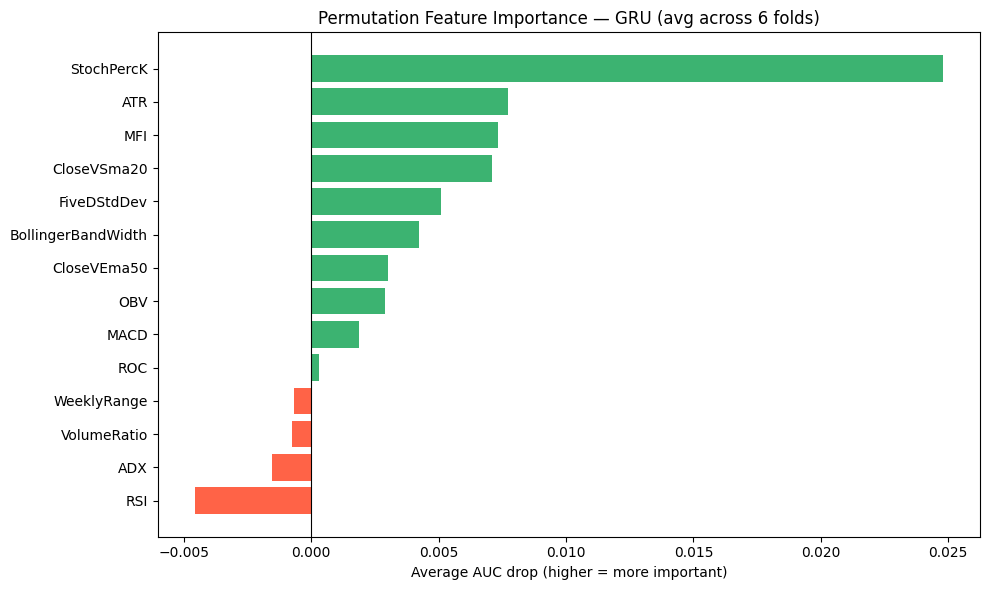

Feature importance (avg AUC drop when shuffled):
StochPercK            0.02478
ATR                   0.00772
MFI                   0.00734
CloseVSma20           0.00710
FiveDStdDev           0.00510
BollingerBandWidth    0.00424
CloseVEma50           0.00302
OBV                   0.00290
MACD                  0.00187
ROC                   0.00030
WeeklyRange          -0.00066
VolumeRatio          -0.00075
ADX                  -0.00153
RSI                  -0.00456


In [30]:
imp_df = pd.DataFrame(fold_importances).T
imp_df.columns = [f['test_year'] for f in FOLDS]
imp_df['Avg AUC drop'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Avg AUC drop', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['mediumseagreen' if v >= 0 else 'tomato' for v in imp_df['Avg AUC drop']]
ax.barh(imp_df.index, imp_df['Avg AUC drop'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Average AUC drop (higher = more important)')
ax.set_title('Permutation Feature Importance — GRU (avg across 6 folds)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print('Feature importance (avg AUC drop when shuffled):')
print(imp_df['Avg AUC drop'].round(5).to_string())

## 8. Hyperparameter Analysis

In [31]:
params_df = pd.DataFrame(fold_best_params,
                         index=[f['test_year'] for f in FOLDS])
params_df.index.name = 'Test year'
print('Best hyperparameters per fold:')
print(params_df.to_string())
print()
print('Most common values selected:')
for col in ['hidden_size', 'dropout', 'l1_weight']:
    mode_val = params_df[col].mode()[0]
    pct      = (params_df[col] == mode_val).mean() * 100
    print(f'  {col:15s}: {mode_val}  ({pct:.0f}% of folds)')

Best hyperparameters per fold:
           hidden_size  dropout  l1_weight
Test year                                 
2019                16      0.3     0.0001
2020                16      0.2     0.0000
2021                16      0.3     0.0001
2022                16      0.2     0.0001
2023                 8      0.2     0.0001
2024                16      0.2     0.0001

Most common values selected:
  hidden_size    : 16  (83% of folds)
  dropout        : 0.2  (67% of folds)
  l1_weight      : 0.0001  (83% of folds)


## 9. Head-to-Head Comparison — GRU vs LSTM

,GRU AUC,LSTM AUC,Baseline
Test year,,,
2019,0.5409,0.5650,0.5262
2021,0.5600,0.5480,0.5136
2022,0.5460,0.5750,0.5878
2023,0.5517,0.5540,0.5110
2024,0.5472,0.5440,0.5726



Average (non-COVID folds):
  GRU AUC:   0.5492
  LSTM AUC:  0.5572   Delta (GRU - LSTM): -0.0080


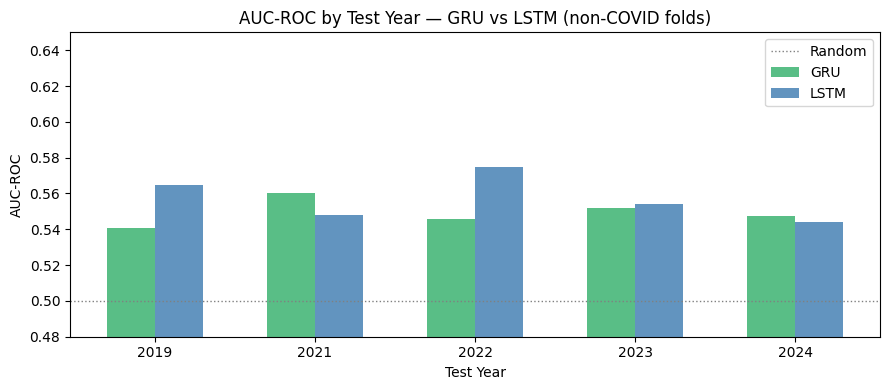

In [32]:
# Direct AUC comparison: GRU vs LSTM per fold (excluding COVID).
# LSTM per-fold values from lstm_model.ipynb.

lstm_per_fold = {2019: 0.5650, 2021: 0.5480, 2022: 0.5750, 2023: 0.5540, 2024: 0.5440}

rows = []
for row in fold_results:
    yr = row['Test year']
    if yr == 2020:
        continue
    rows.append({
        'Test year':  yr,
        'GRU AUC':    row['AUC-ROC'],
        'LSTM AUC':   lstm_per_fold.get(yr, float('nan')),
        'Baseline':   row['Baseline'],
    })

cmp_df = pd.DataFrame(rows).set_index('Test year')
display(cmp_df.style.format('{:.4f}').highlight_max(
    axis=1, subset=['GRU AUC', 'LSTM AUC'], color='#d4edda'))

print()
gru_avg  = cmp_df['GRU AUC'].mean()
lstm_avg = cmp_df['LSTM AUC'].mean()
print(f'Average (non-COVID folds):')
print(f'  GRU AUC:   {gru_avg:.4f}')
print(f'  LSTM AUC:  {lstm_avg:.4f}   Delta (GRU - LSTM): {gru_avg - lstm_avg:+.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cmp_df))
w = 0.3
ax.bar(x - w/2, cmp_df['GRU AUC'],  w, label='GRU',  color='mediumseagreen', alpha=0.85)
ax.bar(x + w/2, cmp_df['LSTM AUC'], w, label='LSTM', color='steelblue',       alpha=0.85)
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax.set_xticks(x); ax.set_xticklabels(cmp_df.index)
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Test Year — GRU vs LSTM (non-COVID folds)')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

## 10. Secondary Evaluation — COVID Extreme Events

Same setup as all other models: train on 2016–2019 primary rows, test on 291 extreme-event rows from Feb–May 2020.

In [33]:
X_full2, y_full2, years_full2, extreme_flags = build_sequences(
    df_all, FEATURES, TARGET, WINDOW)

mask_pre  = (extreme_flags == 0) & (years_full2 < 2020)
mask_cov  = (extreme_flags == 1)
mask_val_c = (extreme_flags == 0) & (years_full2 == 2019)

X_pre_c, y_pre_c  = X_full2[mask_pre],   y_full2[mask_pre]
X_cov_c, y_cov_c  = X_full2[mask_cov],   y_full2[mask_cov]
X_val_c, y_val_c  = X_full2[mask_val_c], y_full2[mask_val_c]

n_feat = X_pre_c.shape[2]
scaler.fit(X_pre_c.reshape(-1, n_feat))

def sc2(X):
    return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape).astype(np.float32)

covid_params = fold_best_params[1]  # params from fold testing on 2020
torch.manual_seed(42)
covid_model, _ = fit_model(sc2(X_pre_c), y_pre_c, sc2(X_val_c), y_val_c, **covid_params)

cov_auc, cov_acc, cov_proba = evaluate(covid_model, sc2(X_cov_c), y_cov_c)
cov_preds    = (cov_proba >= 0.5).astype(int)
cov_baseline = max(y_cov_c.mean(), 1 - y_cov_c.mean())

print('Secondary evaluation — COVID extreme events (Feb–May 2020):')
print(f'  Metric          GRU         LSTM        LogReg')
print(f'  {"---":44s}')
print(f'  Accuracy         {cov_acc:.4f}      0.5464      —')
print(f'  Precision        {precision_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.4968      —')
print(f'  Recall           {recall_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.5954      —')
print(f'  F1               {f1_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.5417      —')
print(f'  AUC-ROC          {cov_auc:.4f}      0.5412      0.7810')
print(f'  Baseline         {cov_baseline:.4f}      0.5498      —')

Secondary evaluation — COVID extreme events (Feb–May 2020):
  Metric          GRU         LSTM        LogReg
  ---                                         
  Accuracy         0.5842      0.5464      —
  Precision        0.5368      0.4968      —
  Recall           0.5573      0.5954      —
  F1               0.5468      0.5417      —
  AUC-ROC          0.5653      0.5412      0.7810
  Baseline         0.5498      0.5498      —


## 11. GRU + Autocorrelated Feature Selection

**Motivation:** Not all 14 features help the GRU equally. The Durbin-Watson test showed all features are autocorrelated in themselves — but that doesn't mean their past values predict GapUp. The better criterion: does `feature(t−k)` correlate significantly with `GapUp(t)` at any lag k ∈ {1,2,3,4}?

**Method — Lagged Cross-Correlation:**  
For each feature and each lag, compute Pearson correlation between the lagged feature and GapUp per ticker, then test whether the mean correlation across tickers is significantly different from zero (one-sample t-test). Features with min p-value < 0.05 across lags are retained.

**Known result from `lstm_auto_correlated_metric.ipynb`:** this drops OBV, VolumeRatio, and ATR — the three features with no significant lagged predictive signal. Notably, ROC (which DW dropped as 'white noise') is retained here because it has significant lagged correlation at lags 2–3.

In [ ]:
from scipy import stats as scipy_stats

# Per-ticker lagged cross-correlation: feature(t-lag) vs GapUp(t)
LAGS = list(range(1, WINDOW + 1))   # [1, 2, 3, 4]
lag_cors = {feat: {lag: [] for lag in LAGS} for feat in FEATURES}

for ticker, grp in primary.sort_values(['Ticker', 'Date']).groupby('Ticker'):
    grp = grp.reset_index(drop=True)
    if len(grp) < 20:
        continue
    for feat in FEATURES:
        for lag in LAGS:
            x    = grp[feat].shift(lag)
            y    = grp[TARGET]
            mask = x.notna()
            xv, yv = x[mask].values, y[mask].values
            if len(xv) < 10:
                continue
            r, _ = scipy_stats.pearsonr(xv, yv)
            lag_cors[feat][lag].append(r)

# Aggregate: mean r and t-test significance per (feature, lag)
lag_rows = []
for feat in FEATURES:
    row = {'feature': feat}
    for lag in LAGS:
        cors = lag_cors[feat][lag]
        if len(cors) >= 3:
            _, p = scipy_stats.ttest_1samp(cors, 0)
            row[f'r_lag{lag}'] = np.mean(cors)
            row[f'p_lag{lag}'] = p
        else:
            row[f'r_lag{lag}'] = 0.0
            row[f'p_lag{lag}'] = 1.0
    row['max_abs_r'] = max(abs(row[f'r_lag{l}']) for l in LAGS)
    row['min_p']     = min(row[f'p_lag{l}'] for l in LAGS)
    lag_rows.append(row)

lagcc_df = pd.DataFrame(lag_rows).set_index('feature').sort_values('max_abs_r', ascending=False)

# Select features where any lag is significant
CC_THRESHOLD    = 0.05
gru_ac_features = lagcc_df[lagcc_df['min_p'] < CC_THRESHOLD].index.tolist()
dropped_feats   = [f for f in FEATURES if f not in gru_ac_features]

print(f'Lagged cross-correlation selection (p < {CC_THRESHOLD}):')
print(f'  Kept   ({len(gru_ac_features)}): {gru_ac_features}')
print(f'  Dropped ({len(dropped_feats)}): {dropped_feats}')
print()

# Heatmap of lagged correlations
r_cols  = [f'r_lag{l}' for l in LAGS]
r_mat   = lagcc_df[r_cols].values
feats_o = lagcc_df.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

vmax = np.abs(r_mat).max()
im   = ax1.imshow(r_mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax1.set_xticks(range(len(LAGS)))
ax1.set_xticklabels([f'lag {l}' for l in LAGS])
ax1.set_yticks(range(len(feats_o)))
ax1.set_yticklabels(feats_o)
for i in range(len(feats_o)):
    for j in range(len(LAGS)):
        ax1.text(j, i, f'{r_mat[i,j]:+.3f}', ha='center', va='center',
                 fontsize=7.5, color='white' if abs(r_mat[i,j]) > vmax*0.5 else 'black')
plt.colorbar(im, ax=ax1, label='Mean Pearson r')
ax1.set_title('feature(t−lag) vs GapUp(t)', fontsize=10)

neg_log_p = -np.log10(lagcc_df['min_p'].clip(lower=1e-10))
colors    = ['mediumseagreen' if p < CC_THRESHOLD else 'lightgrey'
             for p in lagcc_df['min_p']]
ax2.barh(feats_o, neg_log_p, color=colors, alpha=0.85)
ax2.axvline(-np.log10(CC_THRESHOLD), color='tomato', ls='--', lw=1.5,
            label=f'p={CC_THRESHOLD} threshold')
ax2.set_xlabel('−log₁₀(min p-value across lags)')
ax2.set_title('Predictive significance — green bars selected', fontsize=10)
ax2.invert_yaxis(); ax2.legend()

plt.suptitle('Lagged Cross-Correlation: feature(t−lag) vs GapUp(t)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# GRU walk-forward with autocorrelation-selected features.
# Same PARAM_GRID, same folds, same preprocessing — only the feature set changes.

X_ac_all, _, _, _ = build_sequences(primary, gru_ac_features, TARGET, WINDOW)
print(f'Sequence shape — AC features: {X_ac_all.shape}')
print(f'Sequence shape — all features: {X_all.shape}')
print()

fold_results_ac     = []
fold_best_params_ac = []
fold_proba_ac       = []
fold_y_test_ac      = []

scaler_ac = StandardScaler()

for fold in FOLDS:
    test_year     = fold['test_year']
    train_years   = fold['train_years']
    inner_val_yr  = max(train_years)
    inner_trn_yrs = [y for y in train_years if y != inner_val_yr]

    mask_itrn = np.isin(years_all, inner_trn_yrs)
    mask_ival  = (years_all == inner_val_yr)
    mask_full  = np.isin(years_all, train_years)
    mask_test  = (years_all == test_year)

    X_itrn, y_itrn = X_ac_all[mask_itrn], y_all[mask_itrn]
    X_ival,  y_ival  = X_ac_all[mask_ival],  y_all[mask_ival]
    X_full,  y_full  = X_ac_all[mask_full],  y_all[mask_full]
    X_test,  y_test  = X_ac_all[mask_test],  y_all[mask_test]

    nf = X_full.shape[2]
    scaler_ac.fit(X_full.reshape(-1, nf))

    def sc_ac(X):
        return scaler_ac.transform(X.reshape(-1, nf)).reshape(X.shape).astype(np.float32)

    Xi_s = sc_ac(X_itrn); Xv_s = sc_ac(X_ival)
    Xf_s = sc_ac(X_full); Xt_s = sc_ac(X_test)

    best_val_auc, best_params = -np.inf, None
    for params in PARAM_GRID:
        torch.manual_seed(42)
        _, val_auc = fit_model(Xi_s, y_itrn, Xv_s, y_ival, **params)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_params  = params.copy()

    torch.manual_seed(42)
    best_model, _ = fit_model(Xf_s, y_full, Xv_s, y_ival, **best_params)

    auc, acc, proba = evaluate(best_model, Xt_s, y_test)
    preds    = (proba >= 0.5).astype(int)
    baseline = max(y_test.mean(), 1 - y_test.mean())

    fold_results_ac.append({
        'Test year':   test_year,
        'Accuracy':    round(acc, 4),
        'Precision':   round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':      round(recall_score(y_test, preds, zero_division=0), 4),
        'F1':          round(f1_score(y_test, preds, zero_division=0), 4),
        'AUC-ROC':     round(auc, 4),
        'Baseline':    round(baseline, 4),
        'hidden_size': best_params['hidden_size'],
        'dropout':     best_params['dropout'],
        'l1_weight':   best_params['l1_weight'],
    })
    fold_best_params_ac.append(best_params)
    fold_proba_ac.append(proba)
    fold_y_test_ac.append(y_test)

    h = best_params['hidden_size']; dr = best_params['dropout']; l1 = best_params['l1_weight']
    print(f'Fold test={test_year} | hidden={h:2d} dropout={dr} l1={l1:.0e} | '
          f'Acc={acc:.3f} AUC={auc:.3f}')

In [ ]:
# Side-by-side: GRU (14 feats) vs GRU+AutoCorr (selected feats)

results_ac_df = pd.DataFrame(fold_results_ac).set_index('Test year')
non_covid_ac  = results_ac_df[results_ac_df.index != 2020]

n_ac  = len(gru_ac_features)
orig_auc_arr = results_df['AUC-ROC'].values
ac_auc_arr   = results_ac_df['AUC-ROC'].values
test_yrs     = results_df.index.tolist()

orig_avg = non_covid['AUC-ROC'].mean()
ac_avg   = non_covid_ac['AUC-ROC'].mean()
delta    = ac_avg - orig_avg

print(f'Average AUC-ROC (non-COVID folds):')
print(f'  GRU — 14 features        : {orig_avg:.4f}')
print(f'  GRU — {n_ac} AC features  : {ac_avg:.4f}   Δ = {delta:+.4f}')
print()

# Per-fold table
cmp_df = pd.DataFrame({
    f'GRU (14 feats)':      results_df['AUC-ROC'],
    f'GRU+AC ({n_ac} feats)': results_ac_df['AUC-ROC'],
    'Baseline':             results_df['Baseline'],
})
display(cmp_df.style
    .format('{:.4f}')
    .highlight_max(axis=1, subset=[f'GRU (14 feats)', f'GRU+AC ({n_ac} feats)'],
                   color='#d4edda')
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

# Line + bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(test_yrs, orig_auc_arr, 'o-',  color='mediumseagreen', lw=2, ms=7,
         label=f'GRU — 14 feats (avg {orig_avg:.4f})')
ax1.plot(test_yrs, ac_auc_arr,   's--', color='darkorchid',    lw=2, ms=7,
         label=f'GRU+AC — {n_ac} feats (avg {ac_avg:.4f})')
ax1.axhline(0.5, color='grey', ls=':', lw=1)
ax1.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.5, label='COVID fold')
ax1.set_xlabel('Test Year'); ax1.set_ylabel('AUC-ROC')
ax1.set_title('Walk-Forward AUC — GRU vs GRU+AutoCorr')
ax1.legend(fontsize=9); ax1.set_ylim(0.48, 0.65)

labels = [f'GRU\n(14 feats)', f'GRU+AC\n({n_ac} feats)']
avgs   = [orig_avg, ac_avg]
bars   = ax2.bar(labels, avgs, color=['mediumseagreen', 'darkorchid'],
                 alpha=0.85, width=0.35)
ax2.axhline(0.5, color='grey', ls=':', lw=1)
for bar, val in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg AUC-ROC (non-COVID folds)')
ax2.set_title('Average AUC — GRU Variants')
ax2.set_ylim(0.50, max(avgs) + 0.025)

plt.suptitle('GRU: Original Features vs Autocorrelation-Selected Features',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Summary

In [34]:
gru_avg_auc = non_covid['AUC-ROC'].mean()
gru_avg_acc = non_covid['Accuracy'].mean()
gru_avg_f1  = non_covid['F1'].mean()
mode_hidden = params_df['hidden_size'].mode()[0]
mode_drop   = params_df['dropout'].mode()[0]
mode_l1     = params_df['l1_weight'].mode()[0]
top5 = imp_df['Avg AUC drop'].head(5)

print('=' * 65)
print('IMPROVED GRU — RESULTS SUMMARY')
print('=' * 65)
print(f'Model:       BidirGRUGapPredictor (bidirectional, elastic-net reg)')
print(f'Features:    {len(FEATURES)} technical (no fundamentals)')
print(f'Window:      {WINDOW} weeks')
print(f'Scaling:     StandardScaler (fit on training sequences only)')
print(f'Validation:  Rolling 3-year walk-forward, 6 folds (2019–2024)')
print()
print('Most common hyperparameters selected:')
print(f'  hidden_size  : {mode_hidden}  (smaller → less overfitting)')
print(f'  dropout      : {mode_drop}')
print(f'  l1_weight    : {mode_l1:.0e}  (0 = L2-only, 1e-4 = elastic net)')
print(f'  weight_decay : 1e-4  (L2, fixed)')
print()
print('Primary evaluation (excluding COVID fold 2020):')
print(f'  Avg Accuracy:  {gru_avg_acc:.4f}   (baseline GRU: ~0.5325)')
print(f'  Avg F1:        {gru_avg_f1:.4f}   (baseline GRU: ~0.5601)')
print(f'  Avg AUC-ROC:   {gru_avg_auc:.4f}   (baseline GRU: ~0.5573, LSTM: 0.5573, LogReg: 0.5736)')
print(f'  Avg Baseline:  {non_covid["Baseline"].mean():.4f}')
print()
print('Top 5 features by permutation importance:')
for feat, drop in top5.items():
    print(f'  {feat:25s}  drop={drop:.5f}')
print()
print(f'COVID secondary AUC: {cov_auc:.4f}  (LSTM: 0.5412, LogReg: 0.7810)')
print()
print('-' * 65)
print('MODEL COMPARISON (non-COVID, Avg AUC-ROC):')
print(f'  Majority class baseline    : 0.500')
print(f'  Improved GRU (bidir+reg)   : {gru_avg_auc:.4f}')
print(f'  LSTM                       : 0.5573')
print(f'  XGBoost                    : 0.5663')
print(f'  Logistic Regression        : 0.5736')
print('=' * 65)

IMPROVED GRU — RESULTS SUMMARY
Model:       BidirGRUGapPredictor (bidirectional, elastic-net reg)
Features:    14 technical (no fundamentals)
Window:      4 weeks
Scaling:     StandardScaler (fit on training sequences only)
Validation:  Rolling 3-year walk-forward, 6 folds (2019–2024)

Most common hyperparameters selected:
  hidden_size  : 16  (smaller → less overfitting)
  dropout      : 0.2
  l1_weight    : 1e-04  (0 = L2-only, 1e-4 = elastic net)
  weight_decay : 1e-4  (L2, fixed)

Primary evaluation (excluding COVID fold 2020):
  Avg Accuracy:  0.5291   (baseline GRU: ~0.5325)
  Avg F1:        0.5628   (baseline GRU: ~0.5601)
  Avg AUC-ROC:   0.5492   (baseline GRU: ~0.5573, LSTM: 0.5573, LogReg: 0.5736)
  Avg Baseline:  0.5422

Top 5 features by permutation importance:
  StochPercK                 drop=0.02478
  ATR                        drop=0.00772
  MFI                        drop=0.00734
  CloseVSma20                drop=0.00710
  FiveDStdDev                drop=0.00510

COVI